<!-- @format -->

# Homework 4

Deadline: 2nd February 23:59, delivered to your tutor.


<!-- @format -->

# Exercise: Understanding Independence and Correlation

## Background Information

1. **Independence of Random Variables**  
   Two random variables $X$ and $Y$ are said to be independent if the occurrence of one does not affect the probability of the other. Mathematically, this means:

   $$
   P(X \leq x, Y \leq y) = P(X \leq x)P(Y \leq y) \quad \text{for all } x, y.
   $$

   Equivalently, their joint probability density function (pdf) or mass function can be written as the product of their marginal pdfs or mass functions:

   $$
   f_{X,Y}(x, y) = f_X(x)f_Y(y).
   $$

2. **Correlation**  
   The correlation between two random variables $X$ and $Y$ is a measure of their linear relationship, defined as:
   $$
   \rho(X, Y) = \frac{\text{Cov}(X, Y)}{\sqrt{\text{Var}(X)\text{Var}(Y)}}.
   $$
   Here, $\text{Cov}(X, Y)$ is the covariance of $X$ and $Y$, and $\text{Var}(X)$ and $\text{Var}(Y)$ are their variances. If $\rho(X, Y) = 0$, it means there is no linear relationship between $X$ and $Y$, but they may still be dependent.

---


<!-- @format -->

## Task 1a (0.5p)

Find a specific example of two random variables $X$ and $Y$ such that:

- $X$ and $Y$ are dependent.
- The correlation $\rho(X, Y)$ is equal to $0$.

Attach proof, either as markdown code, or photo.


<!-- @format -->

Let’s take $X, Y$,such that $X \sim  N(0,1),\ Y=X^2$

$$
P_X =
\begin{cases}
X = -1: \frac{2}{5} \\
X = 0: \frac{1}{5} \\
X = 1: \frac{2}{5}
\end{cases}

P_Y =
\begin{cases}
Y = 0: \frac{1}{5} \\
Y = 1: \frac{4}{5}
\end{cases}
$$

We know that

$$
   \rho(X, Y) = \frac{\text{Cov}(X, Y)}{\sqrt{\text{Var}(X)\text{Var}(Y)}}
$$

Also, we will use

$$
\text{cov}(X,Y) = E[XY] - EX \cdot EY
$$

Computing the expected values:

- $EX = \sum_i x_i p_i = -1 \cdot \frac{2}{5} + 0 \cdot \frac{1}{5} + 1 \cdot \frac{2}{5} = 0$

- $EY =  0 \cdot \frac{1}{5} + 1 \cdot \frac{4}{5} = \frac{4}{5}$

- $E[X^2] = (-1)^2 \cdot \frac{2}{5} + 0^2 \cdot \frac{1}{5} + 1^2 \cdot \frac{2}{5} = \frac{4}{5}$

- $E[Y^2] =  0^2 \cdot \frac{1}{5} + 1^2 \cdot \frac{4}{5} = \frac{4}{5}$
- $E[XY] = E[X^3] = (-1)^3 \cdot \frac{2}{5} + 0^3 \cdot \frac{1}{5} + 1^3 \cdot \frac{2}{5} = 0$

Using the formula:

$$\text{Var}(X) = E[X^2] - (E[X])^2$$

- $\text{Var}(X) = \frac{4}{5} - 0^2 = \frac{4}{5}$
- $\text{Var}(Y) = \frac{4}{5} - (\frac{4}{5})^2 = \frac{4}{25}$

Computing covariance

$$
\text{cov}(X,Y) = 0 - 0 \cdot \frac{4}{5} = 0
$$

Thus, we obtain:

$$
   \rho(X, Y) = \frac{0}{\sqrt{\text{Var}(X)\text{Var}(Y)}} = 0,  \ \text{cause} \ \text{Var}(X)\text{Var}(Y) > 0
$$

$\square$

<!-- @format -->

## Task 1b (0.5p)

You are given data file `data.csv`.

- Load the data and do the pairplots of features and target, what can you observe?
- Compute the correlations and plot, the correlation matrix, what can you conclude?
- Train a random forest prediction and plot the histogram of feature importances. How does it align with previous observations?

**Write your answers clearly!**


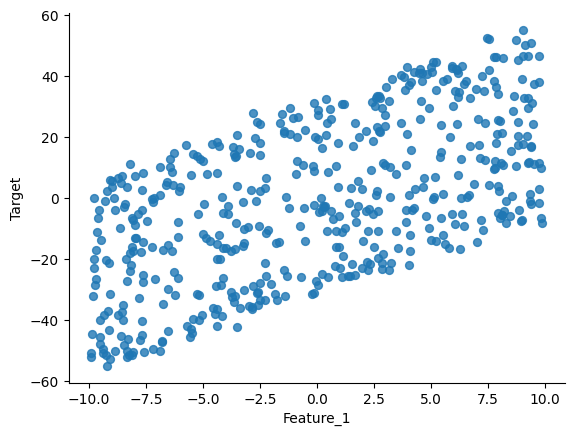

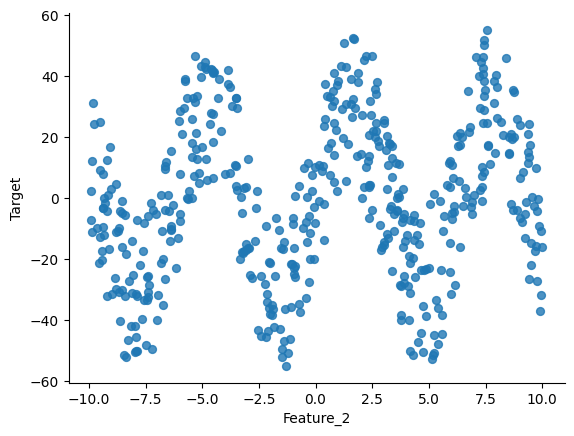

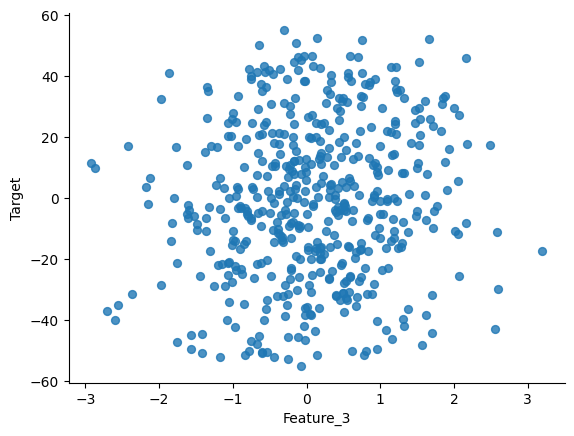

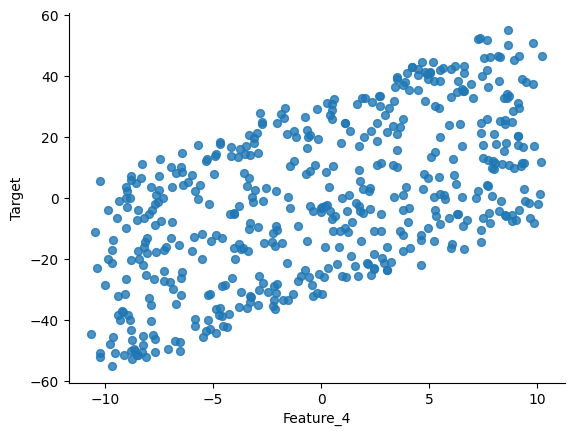

In [6]:
# prompt: correlations of random features with target

import numpy as np
import pandas as pd
from matplotlib import pyplot as plt

# ... (Your existing code) ...
data = pd.read_csv("data.csv")


# @title Features vs Target
data.plot(kind="scatter", x="Feature_1", y="Target", s=32, alpha=0.8)
plt.gca().spines[
    [
        "top",
        "right",
    ]
].set_visible(False)
plt.show()

data.plot(kind="scatter", x="Feature_2", y="Target", s=32, alpha=0.8)
plt.gca().spines[
    [
        "top",
        "right",
    ]
].set_visible(False)
plt.show()

data.plot(kind="scatter", x="Feature_3", y="Target", s=32, alpha=0.8)
plt.gca().spines[
    [
        "top",
        "right",
    ]
].set_visible(False)
plt.show()

data.plot(kind="scatter", x="Feature_4", y="Target", s=32, alpha=0.8)
plt.gca().spines[
    [
        "top",
        "right",
    ]
].set_visible(False)
plt.show()

 - Feature 1 and Feature 4 look almost identical; they are highly correlated with the target, showing a clear linear trend
- Feature 2 appears to be correlated with the target, but the relationship seems to be non-linear.
- Feature 3 looks like random noise
- Feature 2 and Feature 3 do not appear to be correlated with each other

           Feature_1  Feature_2  Feature_3  Feature_4    Target
Feature_1   1.000000   0.044031   0.038552   0.996672  0.600176
Feature_2   0.044031   1.000000  -0.022952   0.042055  0.179238
Feature_3   0.038552  -0.022952   1.000000   0.038521  0.111958
Feature_4   0.996672   0.042055   0.038521   1.000000  0.593566
Target      0.600176   0.179238   0.111958   0.593566  1.000000


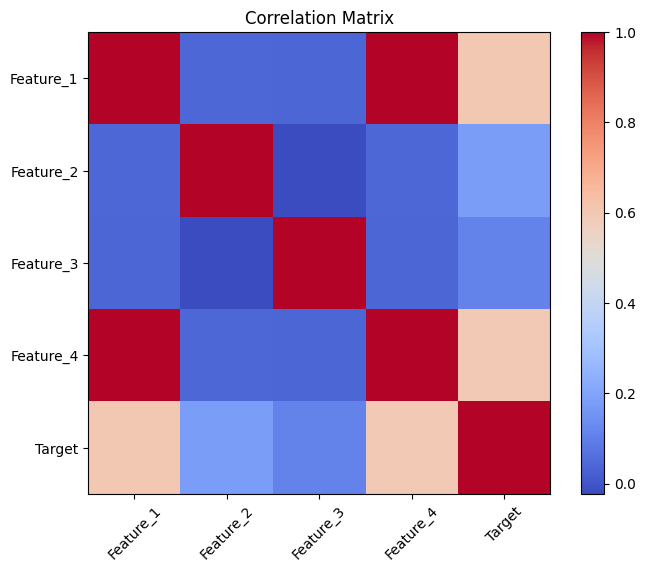

In [7]:
# prompt: correlations of random features with target

import numpy as np
import pandas as pd
from matplotlib import pyplot as plt

# ... (Your existing code) ...

# Calculate correlations
correlations = data.corr()

# Print the correlation matrix
print(correlations)

# Visualize the correlations (optional)
plt.figure(figsize=(8, 6))
plt.imshow(correlations, cmap="coolwarm", interpolation="nearest")
plt.colorbar()
plt.xticks(range(len(correlations)), correlations.columns, rotation=45)
plt.yticks(range(len(correlations)), correlations.columns)
plt.title("Correlation Matrix")
plt.show()

- Feature 1 and Feature 4 are highly correlated, as the correlation matrix returns a score of $0.996672$ for these features 
- Feature 1 and Feature 4 are moderately correlated with the target, with scores of $0.600176$ and $0.593566$, respectively
- Feature 2 is not linearly correlated with the target
- The remaining comparisons show no significant correlation with each other

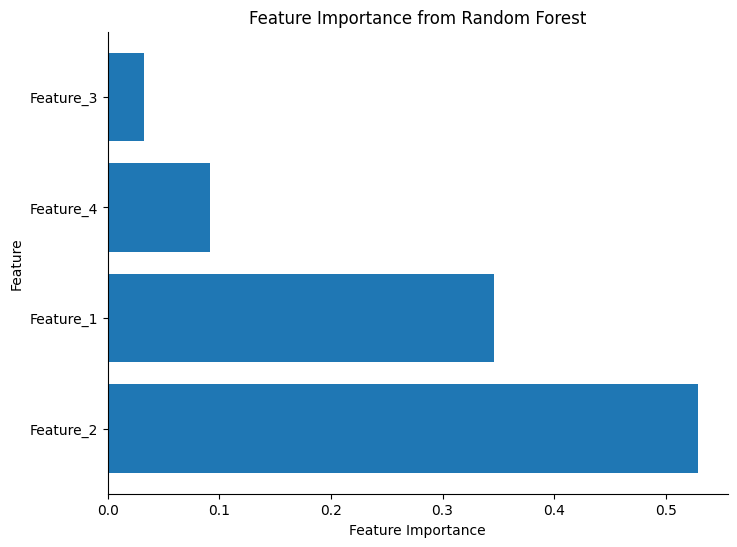

In [9]:
# prompt: do the same plot as above but ionstead of correlation use feature importance from random forest

import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from sklearn.ensemble import RandomForestRegressor

# ... (Your existing code) ...

# Calculate feature importances using RandomForest
rf = RandomForestRegressor(random_state=42)
rf.fit(data.drop("Target", axis=1), data["Target"])
importances = rf.feature_importances_

# Create a DataFrame for visualization
importance_df = pd.DataFrame(
    {"Feature": data.drop("Target", axis=1).columns, "Importance": importances}
)
importance_df = importance_df.sort_values(by="Importance", ascending=False)


# Visualize feature importances
plt.figure(figsize=(8, 6))
plt.barh(importance_df["Feature"], importance_df["Importance"])
plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Feature Importance from Random Forest")
plt.gca().spines[
    [
        "top",
        "right",
    ]
].set_visible(False)
plt.show()

- As we mentioned earlier, the correlation matrix does not show a linear correlation between Feature 2 and the target. Here we see that feature 2 is strongly correlated with the target, which indicates a non-linear relationship
- Feature 1 is again strongly correlated with the target
- Feature 3 appears to be only random noise and has no impact on the target 
- Feature 4 has no significant impact on the target, even though its plot looks very similar to Feature 1

<!-- @format -->

# Problem 2

Consider any dataset $X \in \mathbb{R}_n^d$, where $d$ is the number of columns, and $n$ is the number of samples. Let $\sum_{i=1}^d \mathcal{D}^2 X^i$ be the sum of variances of all the columns. Let $X_{pca} \in \mathbb{R}_n^d$ be the PCA transformed $X$ dataset. Show that $\sum_{i=1}^d \mathcal{D}^2 X^i = \sum_{i=1}^d \mathcal{D}^2 X_{pca}^i$.

Write the proof of this fact below. You can either do it in LaTeX, or you can write it in a reasonably elegant way on a piece of paper and paste an image here.


## Proof
PCA transforms the dataset into a new basis where the principal components are uncorrelated.

The transformation is given by:

  $$
  X_{pca} = X W
  $$

  where $W$ is an orthogonal matrix containing the eigenvectors of the covariance matrix $\Sigma_X$.
  
  
The total variance in a dataset is defined as:

  $$
  \sum_{i=1}^{d} \mathcal{D}^2 X^i = \text{Tr}(\Sigma_X)
  $$

  where $\Sigma_X = \frac{1}{n} X^T X$ is the covariance matrix of $X$, and **Tr** denotes the trace (sum of eigenvalues).
PCA diagonalizes the covariance matrix, meaning that:

  $$
  \Sigma_{X_{pca}} = W^T \Sigma_X W
  $$

  Since $W$ is an orthogonal matrix, it preserves the trace, so:

$$
  \text{Tr}(\Sigma_{X_{pca}}) = \text{Tr}(\Sigma_X)
$$

  which implies:

$$
  \sum_{i=1}^{d} \mathcal{D}^2 X^i_{pca} = \sum_{i=1}^{d} \mathcal{D}^2 X^i.
$$


<!-- @format -->

# **Problem 3 (1p)**

In this problem you will use algorithm from Online Learning and Boosting, called Multiplicative Weights Update https://www.cs.princeton.edu/~arora/pubs/MWsurvey.pdf to solve the following optimization problem.

## Problem Definition

- **Input**:
  - Universe $U = \{1, 2, \dots, n\}$
  - Sets $\mathcal{S} = \{S_1, \dots, S_m\},\ S_i \subseteq U$
- **Goal**: Find smallest $\mathcal{C} \subseteq \mathcal{S}$ covering $U$

## Algorithm

**Initialize weights**:

$$
w_u^{(1)} = 1 \quad \forall u \in U
$$

**Repeat until all elements covered**:

1. **Choose set** $S_i$ with probability:

   $$
   \mathbb{P}[S_i] = \frac{\sum_{u \in S_i} w_u^{(t)}}{\sum_{j=1}^m \sum_{u \in S_j} w_u^{(t)}}
   $$

2. **Add** $S_i$ to solution $\mathcal{C}$

3. **Update weights** for uncovered $u \in S_i$:
   $$
   w_u^{(t+1)} = \frac{1}{2}w_u^{(t)}
   $$

## Task

1. Show that the total number of rounds (the number of sets the algorithm returns) is on expectation at most O(\log n) worse than the optimum number of sets needed:
   $$
   \mathbb{E}[T] \leq 2\text{OPT}\ln n
   $$
